# Applied Exercise 7 - Dissimilarity measures in clustering

In [22]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree
from ISLP import load_data
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans

In [2]:
url = "https://vincentarelbundock.github.io/Rdatasets/csv/datasets/USArrests.csv"
USArrests = pd.read_csv(url, index_col=0)
X = USArrests.values
X = (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)

# Euclidean distances and squared distances
D_euclid = pairwise_distances(X)
D_euclid_sq = D_euclid**2

# Correlations between observations
R = np.corrcoef(X)

A = 1 - R
B = D_euclid_sq

print("=" * 60)
print("CORRELATION DISTANCE vs EUCLIDEAN DISTANCE")
print("=" * 60)
print(f"Number of variables: {X.shape[1]}")
print(f"Mean ratio d²/(1-r): {np.mean(B[A > 0] / A[A > 0]):.6f}")
print(f"Maximum difference from 8: {np.max(np.abs(B - 8*A)):.10f}")

CORRELATION DISTANCE vs EUCLIDEAN DISTANCE
Number of variables: 4
Mean ratio d²/(1-r): 7.925596
Maximum difference from 8: 0.0000000000


After standardizing each observation to have mean zero and standard deviation one, the squared Euclidean distance was approximately 8 times (1-r_{ij}) for every pair of states. Hence, for the USArrests data, this confirms the stated proportionality between squared Euclidean distance and correlation-based dissimilarity.

# Applied Exercise 8 - Proportion of Variation explained from PCA

In [3]:
X = StandardScaler().fit_transform(USArrests)
pca = PCA()
pca.fit(X)

# PVE using explained_variance_ratio_
pve_a = pca.explained_variance_ratio_

# PVE using Equation 12.10 from ISL
loadings = pca.components_
eigenvalues = np.sum((X @ loadings.T)**2, axis=0) / (X.shape[0] - 1)
pve_b = eigenvalues / np.sum(eigenvalues)

print("=" * 60)
print("PVE FROM PCA")
print("=" * 60)
print("\nPVE using explained_variance_ratio_:")
print(pve_a)

print("\nPVE using Equation 12.10:")
print(pve_b)

print("\nMaximum difference:")
print(np.max(np.abs(pve_a - pve_b)))

PVE FROM PCA

PVE using explained_variance_ratio_:
[0.62006039 0.24744129 0.0891408  0.04335752]

PVE using Equation 12.10:
[0.62006039 0.24744129 0.0891408  0.04335752]

Maximum difference:
1.1102230246251565e-16


The variances explained from both are similar (the difference is e-17 which is negligible). This confirms that both approaches give the same PVE when PCA is performed on the same centered and scaled data.

# Applied Exercise 9 - Hierarchical Clustering

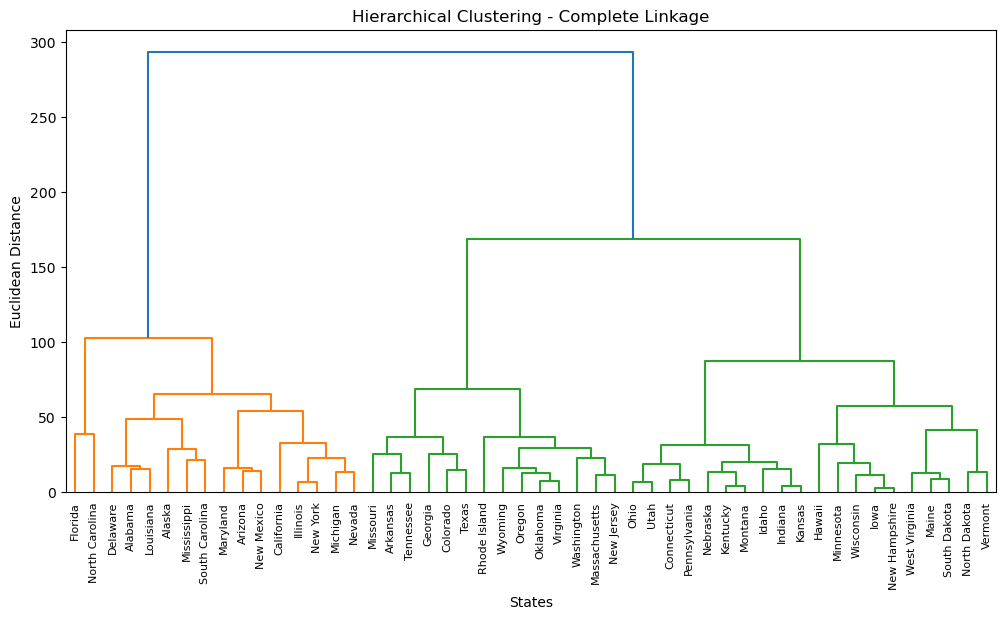

In [4]:
# Complete linkage, Euclidean distance
hc = linkage(USArrests, method="complete", metric="euclidean")

plt.figure(figsize=(12,6))
dendrogram(hc, labels=USArrests.index, leaf_rotation=90)
plt.title("Hierarchical Clustering - Complete Linkage")
plt.xlabel("States")
plt.ylabel("Euclidean Distance")
plt.show()

In [5]:
clusters = cut_tree(hc, n_clusters=3).flatten()

print("=" * 60)
print("CLUSTERS: UNSCALED DATA")
print("=" * 60)

for i in range(3):
    print(f"\nCluster {i+1}:")
    print(", ".join(USArrests.index[clusters == i]))

CLUSTERS: UNSCALED DATA

Cluster 1:
Alabama, Alaska, Arizona, California, Delaware, Florida, Illinois, Louisiana, Maryland, Michigan, Mississippi, Nevada, New Mexico, New York, North Carolina, South Carolina

Cluster 2:
Arkansas, Colorado, Georgia, Massachusetts, Missouri, New Jersey, Oklahoma, Oregon, Rhode Island, Tennessee, Texas, Virginia, Washington, Wyoming

Cluster 3:
Connecticut, Hawaii, Idaho, Indiana, Iowa, Kansas, Kentucky, Maine, Minnesota, Montana, Nebraska, New Hampshire, North Dakota, Ohio, Pennsylvania, South Dakota, Utah, Vermont, West Virginia, Wisconsin


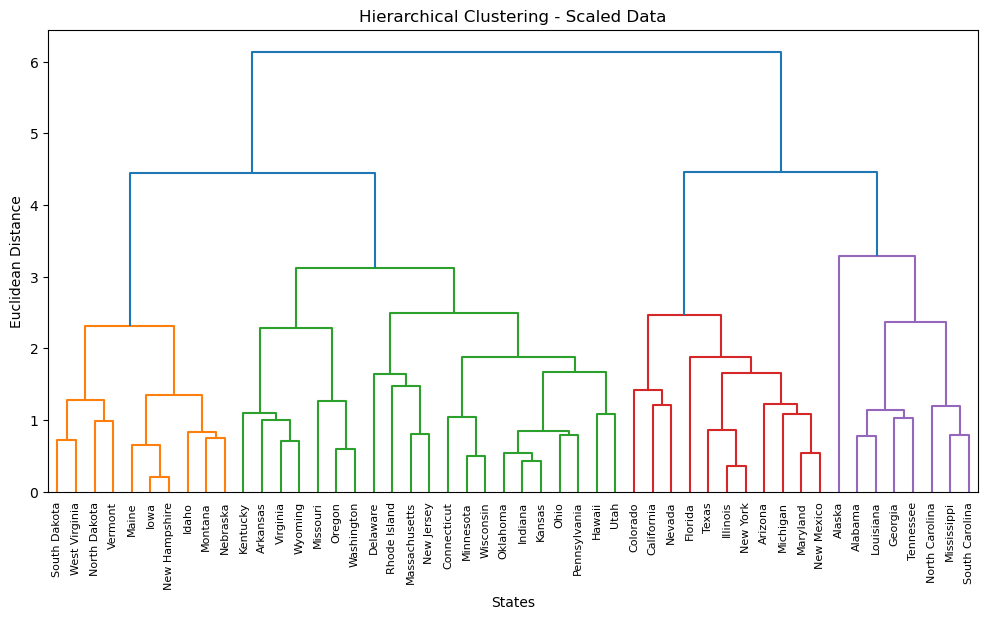

CLUSTERS: SCALED DATA

Cluster 1:
Alabama, Alaska, Georgia, Louisiana, Mississippi, North Carolina, South Carolina, Tennessee

Cluster 2:
Arizona, California, Colorado, Florida, Illinois, Maryland, Michigan, Nevada, New Mexico, New York, Texas

Cluster 3:
Arkansas, Connecticut, Delaware, Hawaii, Idaho, Indiana, Iowa, Kansas, Kentucky, Maine, Massachusetts, Minnesota, Missouri, Montana, Nebraska, New Hampshire, New Jersey, North Dakota, Ohio, Oklahoma, Oregon, Pennsylvania, Rhode Island, South Dakota, Utah, Vermont, Virginia, Washington, West Virginia, Wisconsin, Wyoming


In [6]:
X_scaled = StandardScaler().fit_transform(USArrests)

hc_scaled = linkage(X_scaled, method="complete", metric="euclidean")

plt.figure(figsize=(12,6))
dendrogram(hc_scaled, labels=USArrests.index, leaf_rotation=90)
plt.title("Hierarchical Clustering - Scaled Data")
plt.xlabel("States")
plt.ylabel("Euclidean Distance")
plt.show()

clusters_scaled = cut_tree(hc_scaled, n_clusters=3).flatten()

print("=" * 60)
print("CLUSTERS: SCALED DATA")
print("=" * 60)

for i in range(3):
    print(f"\nCluster {i+1}:")
    print(", ".join(USArrests.index[clusters_scaled == i]))

Scaling changes the hierarchical clustering because the original variables have very different scales. Without scaling, variables with larger numerical ranges, especially Assault, have greater influence on the Euclidean distances. Scaling gives each variable comparable influence which results in 4 clusters after scaling comapred to 2 on unscaled data.

# Applied Exercise 10 - PCA and K-means on simulated data

In [8]:
np.random.seed(1)
n = 20
p = 50
X = np.random.normal(0, 1, (60, p))
true_class = np.repeat([0, 1, 2], n)

# Adding different mean shifts to create 3 classes
X[true_class == 0, :5] += 5
X[true_class == 1, 5:10] += 5
X[true_class == 2, 10:15] += 5

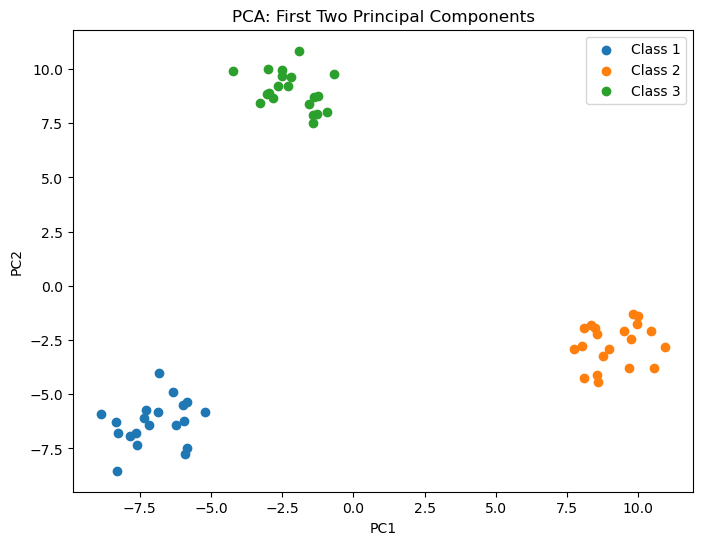

PVE: [0.34337926 0.32167072]


In [9]:
pca = PCA()
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
for c in range(3):
    plt.scatter(X_pca[true_class == c, 0], X_pca[true_class == c, 1], label=f"Class {c+1}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: First Two Principal Components")
plt.legend()
plt.show()

print("PVE:", pca.explained_variance_ratio_[:2])

In [11]:
kmeans3 = KMeans(n_clusters=3, n_init=20, random_state=1)
cluster3 = kmeans3.fit_predict(X)

print("=" * 60)
print("K-MEANS: K = 3")
print("=" * 60)
print(pd.crosstab(true_class, cluster3, rownames=["True Class"], colnames=["Cluster"]))

K-MEANS: K = 3
Cluster      0   1   2
True Class            
0            0  20   0
1           20   0   0
2            0   0  20


K-Means with 3 clusters performs reasonably well as the original data has exactly 3 clusters.

In [12]:
kmeans2 = KMeans(n_clusters=2, n_init=20, random_state=1)
cluster2 = kmeans2.fit_predict(X)

print("=" * 60)
print("K-MEANS: K = 2")
print("=" * 60)
print(pd.crosstab(true_class, cluster2, rownames=["True Class"], colnames=["Cluster"]))

K-MEANS: K = 2
Cluster      0   1
True Class        
0           20   0
1            0  20
2           20   0


With 2 clusters, K-means tries to include 2 groups of points into one cluster and the other group into another cluster.

In [13]:
kmeans4 = KMeans(n_clusters=4, n_init=20, random_state=1)
cluster4 = kmeans4.fit_predict(X)

print("=" * 60)
print("K-MEANS: K = 4")
print("=" * 60)
print(pd.crosstab(true_class, cluster4, rownames=["True Class"], colnames=["Cluster"]))

K-MEANS: K = 4
Cluster     0   1   2   3
True Class               
0           0  20   0   0
1           2   0  18   0
2           0   0   0  20


With 4 clusters, K-means is forced to assign a few slightly fater points from a cluster into another new cluster which in fact is not required.

In [14]:
kmeans_pca = KMeans(n_clusters=3, n_init=20, random_state=1)
cluster_pca = kmeans_pca.fit_predict(X_pca[:, :2])

print("=" * 60)
print("K-MEANS ON FIRST TWO PRINCIPAL COMPONENTS")
print("=" * 60)
print(pd.crosstab(true_class, cluster_pca, rownames=["True Class"], colnames=["Cluster"]))

K-MEANS ON FIRST TWO PRINCIPAL COMPONENTS
Cluster      0   1   2
True Class            
0            0  20   0
1           20   0   0
2            0   0  20


This shows that K-means performs the same with 2 principal components as it was with all the 5 features showing that PCA has reduced the feature set well.

In [15]:
X_scaled = StandardScaler().fit_transform(X)

kmeans_scaled = KMeans(n_clusters=3, n_init=20, random_state=1)
cluster_scaled = kmeans_scaled.fit_predict(X_scaled)

print("=" * 60)
print("K-MEANS: K = 3 AFTER SCALING")
print("=" * 60)
print(pd.crosstab(true_class, cluster_scaled, rownames=["True Class"], colnames=["Cluster"]))

K-MEANS: K = 3 AFTER SCALING
Cluster      0   1   2
True Class            
0            0   0  20
1           20   0   0
2            0  20   0


Scaling the variables changes the clustering because it gives every variable equal variance and reduces the influence of the variables containing the strongest mean shifts. Here, only the cluster numbering changes (which is purely arbitrary) and the grouping remains the smae for this data set split.

# Applied Exercise 11 - Matrix completion using SVD (Single Value Decomposition)

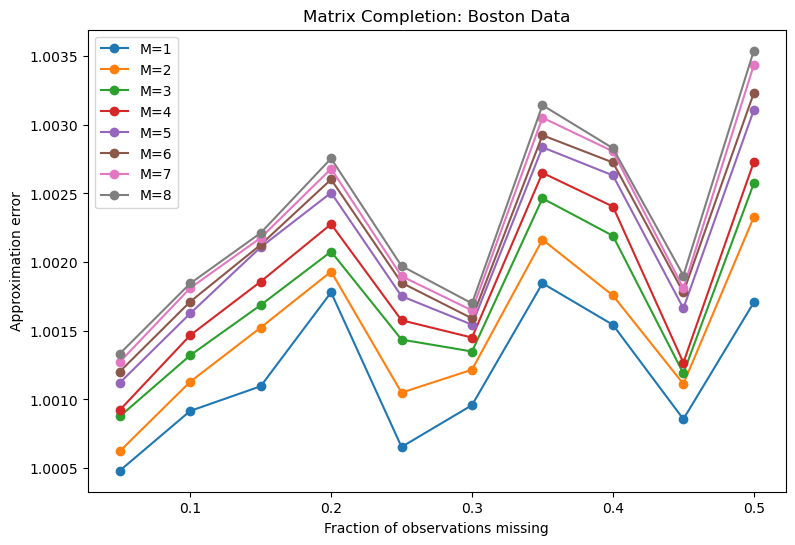

In [17]:
# Algorithm as given in the textbook ISL (SVD here reduced a complex matrix into smaller matrices that is required)
def matrix_completion(X, M, max_iter=100, tol=1e-5, verbose=False):
    X = np.asarray(X, dtype=float)
    missing = np.isnan(X)
    X_hat = X.copy()

    # Initialize missing values with column means
    col_means = np.nanmean(X_hat, axis=0)
    X_hat[missing] = np.take(col_means, np.where(missing)[1])

    errors = []
    for iteration in range(1, max_iter + 1):
        # Rank-M SVD approximation
        U, s, Vt = np.linalg.svd(X_hat, full_matrices=False)
        X_lowrank = (U[:, :M] * s[:M]) @ Vt[:M, :]

        # Relative change on observed entries
        error = np.linalg.norm((X_lowrank - X_hat)[~missing]) / np.linalg.norm(X_hat[~missing])
        errors.append(error)

        # Keep observed values fixed and update only missing values
        X_hat[missing] = X_lowrank[missing]
        if verbose:
            print(f"Iteration {iteration}: relative error = {error:.6f}")
        if error < tol:
            break

    return X_hat, errors

Boston = load_data("Boston")
X = StandardScaler().fit_transform(Boston)

fractions = np.arange(0.05, 0.51, 0.05)
M_values = range(1, 9)
n_reps = 10
results = np.zeros((len(fractions), len(M_values)))
np.random.seed(1)

for f_idx, frac in enumerate(fractions):
    n_missing = int(frac * X.shape[0])

    for rep in range(n_reps):
        # Nested missing observations
        missing_rows = np.random.choice(X.shape[0], n_missing, replace=False)

        X_missing = X.copy()
        X_missing[missing_rows, :] = np.nan

        for m_idx, M in enumerate(M_values):
            X_completed, _ = matrix_completion(X_missing, M)

            # Approximation error on the missing observations
            error = np.linalg.norm(X_completed[missing_rows] - X[missing_rows]) / np.linalg.norm(X[missing_rows])
            results[f_idx, m_idx] += error

results /= n_reps

# Approximation error
plt.figure(figsize=(9, 6))
for m_idx, M in enumerate(M_values):
    plt.plot(fractions, results[:, m_idx], marker="o", label=f"M={M}")

plt.xlabel("Fraction of observations missing")
plt.ylabel("Approximation error")
plt.title("Matrix Completion: Boston Data")
plt.legend()
plt.show()

The approximation error generally increases (wave format can be observed for the above data) as the fraction of missing observations increases. Increasing M (number of principal component vector directions) allows the matrix completion procedure to capture more structure in the data, although the improvement may diminish for larger values of M. The experiment illustrates the trade-off between the rank of the approximation and the amount of missing data.

# Applied Exercise 12 - Matrix completion using PCA

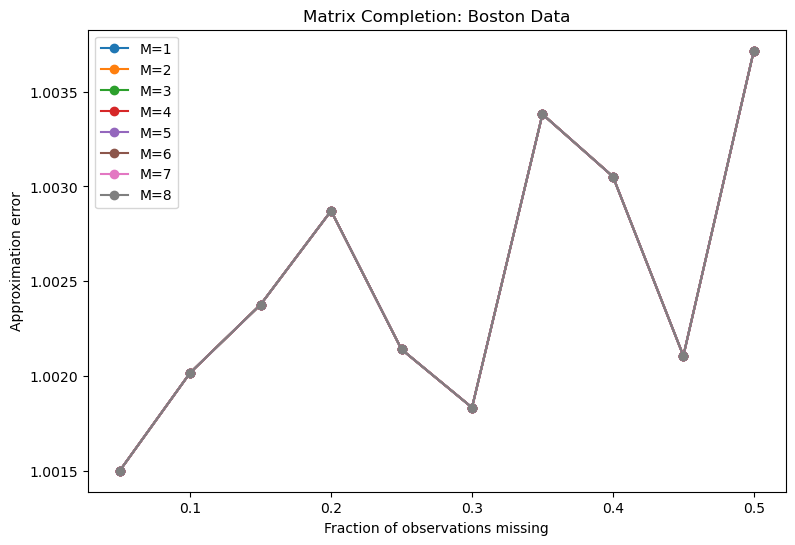

In [21]:
# Algorithm as given in the textbook ISL (using PCA)
import numpy as np
import matplotlib.pyplot as plt
from ISLP import load_data
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Algorithm as given in the textbook ISL (using PCA instead of SVD)
def matrix_completion_pca(X, M, max_iter=100, tol=1e-5, verbose=False):
    X = np.asarray(X, dtype=float)
    missing = np.isnan(X)
    X_hat = X.copy()

    # Initialize missing values with column means
    col_means = np.nanmean(X_hat, axis=0)
    X_hat[missing] = np.take(col_means, np.where(missing)[1])

    errors = []
    for iteration in range(1, max_iter + 1):
        # Rank-M PCA approximation
        pca = PCA(n_components=M)
        X_lowrank = pca.inverse_transform(pca.fit_transform(X_hat))

        # Relative change on observed entries
        error = np.linalg.norm((X_lowrank - X_hat)[~missing]) / np.linalg.norm(X_hat[~missing])
        errors.append(error)

        X_hat[missing] = X_lowrank[missing]
        if verbose:
            print(f"Iteration {iteration}: relative error = {error:.6f}")
        if error < tol:
            break

    return X_hat, errors

Boston = load_data("Boston")
X = StandardScaler().fit_transform(Boston)

fractions = np.arange(0.05, 0.51, 0.05)
M_values = range(1, 9)
n_reps = 10
results = np.zeros((len(fractions), len(M_values)))
np.random.seed(1)

for f_idx, frac in enumerate(fractions):
    n_missing = int(frac * X.shape[0])

    for rep in range(n_reps):
        # Nested missing observations
        missing_rows = np.random.choice(X.shape[0], n_missing, replace=False)

        X_missing = X.copy()
        X_missing[missing_rows, :] = np.nan

        for m_idx, M in enumerate(M_values):
            X_completed, _ = matrix_completion_pca(X_missing, M)

            # Approximation error on the missing observations
            error = np.linalg.norm(X_completed[missing_rows] - X[missing_rows]) / np.linalg.norm(X[missing_rows])
            results[f_idx, m_idx] += error

results /= n_reps

# Approximation error
plt.figure(figsize=(9, 6))
for m_idx, M in enumerate(M_values):
    plt.plot(fractions, results[:, m_idx], marker="o", label=f"M={M}")

plt.xlabel("Fraction of observations missing")
plt.ylabel("Approximation error")
plt.title("Matrix Completion: Boston Data")
plt.legend()
plt.show()

This exercise proves PCA and SVD (with centered data/mean 0) gives the similar results. PCA has all curves almost overlapping showing increase in M (PCA vectors) doesnt have much effect on the approximation.

# Applied Exercise 13 - Hierarchical clustering on Gene data

GENE EXPRESSION DATA
Shape: (1000, 40)


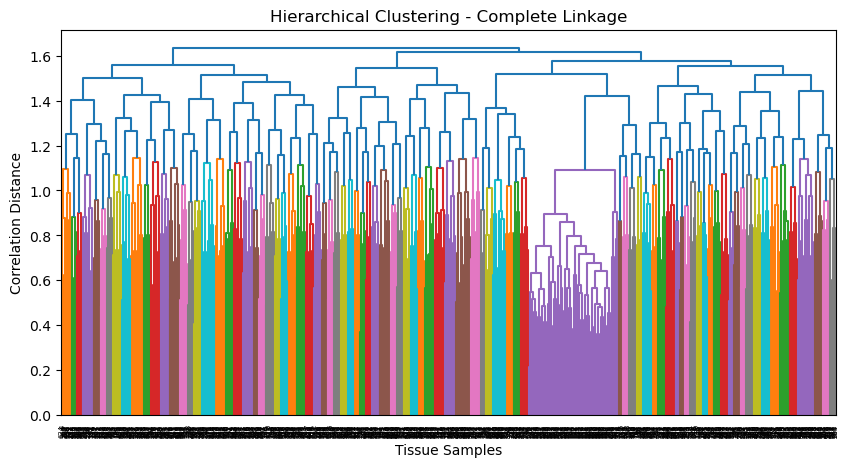

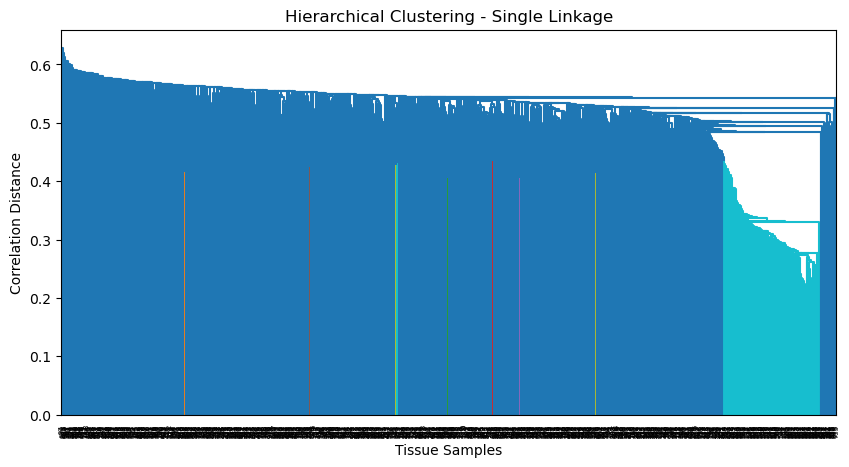

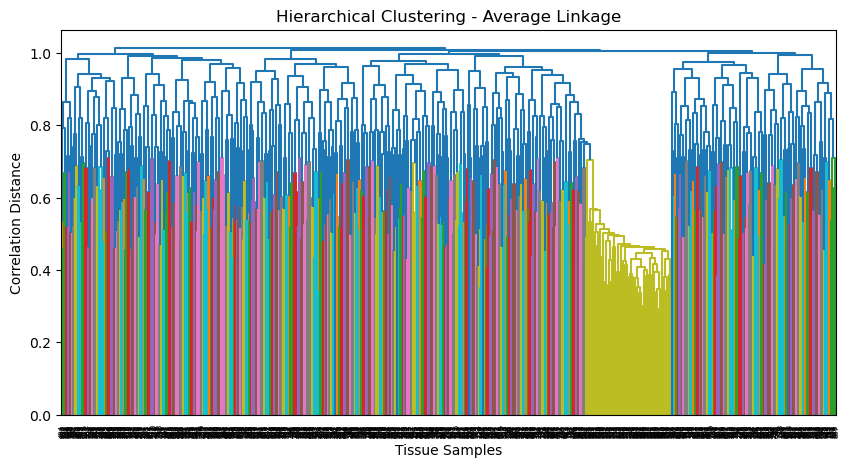

TOP 10 GENES WITH LARGEST GROUP DIFFERENCE
1. Gene 29: mean difference = 1.0808
2. Gene 22: mean difference = 1.0188
3. Gene 40: mean difference = 0.9822
4. Gene 30: mean difference = 0.9772
5. Gene 37: mean difference = 0.9193
6. Gene 26: mean difference = 0.9088
7. Gene 33: mean difference = 0.8618
8. Gene 25: mean difference = 0.8340
9. Gene 36: mean difference = 0.8299
10. Gene 28: mean difference = 0.8274


In [23]:
url = "https://www.statlearning.com/s/Ch12Ex13.csv"
genes = pd.read_csv(url, header=None)

print("=" * 60)
print("GENE EXPRESSION DATA")
print("=" * 60)
print("Shape:", genes.shape)

X = genes.values
D = 1 - np.corrcoef(X)

for method in ["complete", "single", "average"]:
    Z = linkage(D[np.triu_indices_from(D, k=1)], method=method)

    plt.figure(figsize=(10, 5))
    dendrogram(Z)
    plt.title(f"Hierarchical Clustering - {method.capitalize()} Linkage")
    plt.xlabel("Tissue Samples")
    plt.ylabel("Correlation Distance")
    plt.show()

# Genes that differ most between the two groups
group1 = X[:20]
group2 = X[20:]

difference = np.abs(group1.mean(axis=0) - group2.mean(axis=0))
top_genes = np.argsort(difference)[::-1][:10]

print("=" * 60)
print("TOP 10 GENES WITH LARGEST GROUP DIFFERENCE")
print("=" * 60)

for rank, gene in enumerate(top_genes, 1):
    print(f"{rank}. Gene {gene + 1}: mean difference = {difference[gene]:.4f}")

Complete linkage gives a relatively clear separation, while single linkage shows a chaining effect where most observations are put into a single cluster and average linkage produces less distinct grouping. The Gene difference shows which gene has the maximum difference between the diseased and healthy groups.